<a href="https://colab.research.google.com/github/Prerana-Bijekar/DL/blob/main/Practical-6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
# Step 1: Load Dataset
# Built-in CIFAR-10 mini dataset (default for demo)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


In [3]:
# Step 2: Build CNN Model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')  # 10 classes for CIFAR-10
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# Step 3: Train Model
history = model.fit(x_train, y_train, epochs=10, batch_size=64,
                    validation_data=(x_test, y_test), verbose=1)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 95s 117ms/step - accuracy: 0.2959 - loss: 1.8974 - val_accuracy: 0.5171 - val_loss: 1.3342
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 94s 120ms/step - accuracy: 0.5141 - loss: 1.3543 - val_accuracy: 0.5917 - val_loss: 1.1338
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 129s 104ms/step - accuracy: 0.5926 - loss: 1.1632 - val_accuracy: 0.6273 - val_loss: 1.0477
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 107ms/step - accuracy: 0.6338 - loss: 1.0387 - val_accuracy: 0.6735 - val_loss: 0.9277
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 139s 104ms/step - accuracy: 0.6694 - loss: 0.9492 - val_accuracy: 0.6929 - val_loss: 0.8646
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 105ms/step - accuracy: 0.6959 - loss: 0.8779 - val_accuracy: 0.7085 - val_loss: 0.8448
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 104ms/step - accuracy: 0.7103 - loss: 0.8236 - val_accuracy: 0.7023 - val_loss: 0.8649
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 104ms/step - accuracy: 0.7364 - loss:

In [5]:
# Step 4: Evaluate Model
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {acc*100:.2f}%")

Test Accuracy: 72.70%


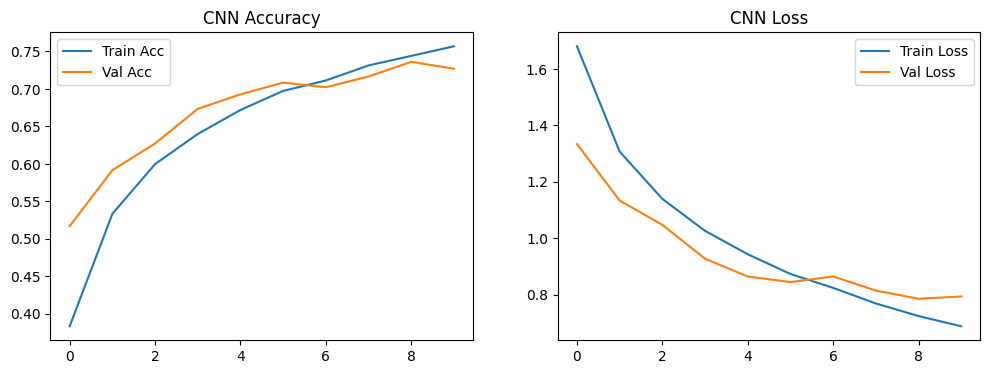

In [6]:
# Step 5: Visualize Training
plt.figure(figsize=(12,4))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("CNN Accuracy")
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("CNN Loss")
plt.legend()

plt.show()